# Logistic Regression Baseline for BNPL Default Risk Prediction





### This notebook develops a **baseline Logistic Regression model** to predict default risk in Buy Now Pay Later (BNPL) transactions.

We begin with a classical machine learning approach due to its simplicity, interpretability, and effectiveness for binary classification problems. This model serves as a benchmark for evaluating more advanced probabilistic models.

The analysis includes:
- Training a logistic regression model on engineered features
- Evaluating performance using Accuracy, ROC-AUC, and confusion matrix
- Interpreting feature importance through model coefficients

This baseline provides a strong reference point for understanding the added value of Bayesian modeling in subsequent notebooks.

In [ ]:
#Importing the libraries for the model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## Data Loading and Initial Setup

In this step, we load the preprocessed and feature-engineered training and testing datasets directly from the project repository. The data has already been cleaned and transformed, allowing us to focus on modeling rather than raw data preprocessing.

The feature set includes numerical variables (such as age, income, and credit score) as well as encoded categorical variables (such as purchase category, device type, and connection type). The target variable represents whether a BNPL transaction resulted in a default.

Since machine learning models typically expect the target variable to be in a one-dimensional format, we convert the response variable into a 1D array where necessary. We also verify the shapes of the datasets and preview the first few rows to ensure that the data has been loaded correctly and is ready for modeling.

In [ ]:
# Load feature-engineered train/test data directly from GitHub

BASE_URL = "https://raw.githubusercontent.com/samarapires-ml/Buy-Now-Pay-Later--BNPL--Risk-Prediction/main/data/feature_engineered"

X_train = pd.read_csv(f"{BASE_URL}/X_train.csv")
X_test  = pd.read_csv(f"{BASE_URL}/X_test.csv")
y_train = pd.read_csv(f"{BASE_URL}/y_train.csv")
y_test  = pd.read_csv(f"{BASE_URL}/y_test.csv")

# Convert y to 1D series
# We do this as model expects y as 1D vector not a dataframe
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.squeeze()

if isinstance(y_test, pd.DataFrame):
    y_test = y_test.squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())

print("\nFirst 5 rows of y_train:")
display(pd.DataFrame(y_train).head())

X_train shape: (40000, 12)
X_test shape:  (10000, 12)
y_train shape: (40000,)
y_test shape:  (10000,)

First 5 rows of X_train:


,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Checkout_Time_Seconds,Gender_Male,Purchase_Category_Electronics,Purchase_Category_Home & Furniture,BNPL_Provider_Afterpay,Device_Type_Mobile,Connection_Type_VPN,Connection_Type_WiFi
0,0.449191,0.678213,1.276992,-0.269804,0.547276,False,False,False,True,True,False,True
1,-1.251365,-0.892115,-0.585550,-0.712582,0.074677,False,False,False,True,False,False,False
2,1.706123,1.499208,1.597902,-0.523022,0.212518,False,False,True,False,False,False,True
3,0.079505,-0.940859,-0.931630,-0.684289,1.512167,False,False,True,True,True,False,True
4,-1.399239,-0.813633,-0.874999,-0.486241,0.114060,True,True,False,False,False,False,False



First 5 rows of y_train:


,target
0,1
1,1
2,0
3,0
4,1


In [ ]:
# Basic checks

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test: ", X_test.isnull().sum().sum())

print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion"))

print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion"))

print("\nFeature columns:")
print(list(X_train.columns))

Missing values in X_train: 0
Missing values in X_test:  0

Target distribution (train):
target
0    0.767975
1    0.232025
Name: proportion, dtype: float64

Target distribution (test):
target
0    0.768
1    0.232
Name: proportion, dtype: float64

Feature columns:
['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount', 'Checkout_Time_Seconds', 'Gender_Male', 'Purchase_Category_Electronics', 'Purchase_Category_Home & Furniture', 'BNPL_Provider_Afterpay', 'Device_Type_Mobile', 'Connection_Type_VPN', 'Connection_Type_WiFi']


## Baseline Model: Logistic Regression

In this step, we build a baseline Logistic Regression model to predict BNPL default risk. This model serves as a benchmark against which the Bayesian approach can be compared.

We use the **liblinear solver**, which is suitable for binary classification problems, and apply **class weighting** to handle class imbalance in the dataset. This ensures that the model does not become biased toward the majority class.

The model is trained on the training data and evaluated on the test set using key performance metrics such as Accuracy, ROC-AUC, and the Classification Report.

In [ ]:
# Baseline Logistic Regression

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",   # helps imbalanced classes
    solver="liblinear",        # stability for binary problems
    random_state=42
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression Results")
print("-----------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Logistic Regression Results
-----------------------------------
Accuracy : 0.6428
ROC-AUC  : 0.7061

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      7680
           1       0.36      0.68      0.47      2320

    accuracy                           0.64     10000
   macro avg       0.61      0.65      0.60     10000
weighted avg       0.75      0.64      0.67     10000



## Model Evaluation and Interpretation

The baseline Logistic Regression model achieves moderate predictive performance. The ROC-AUC score indicates that the model has a reasonable ability to distinguish between default and non-default cases.

From the classification report, we observe that the model performs well in identifying the majority class (non-defaults), but struggles with the minority class (defaults). While recall for the default class is relatively higher, precision is low, indicating that many predicted defaults are incorrect.

This imbalance in performance highlights a common challenge in risk prediction problems, where correctly identifying rare events (defaults) is difficult. These results motivate the use of a Bayesian approach, which can provide more stable estimates and better uncertainty handling.

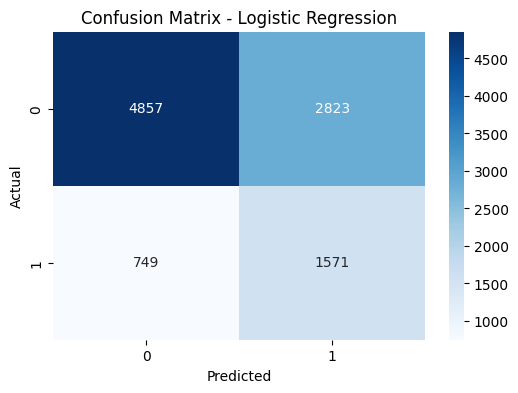

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the model’s classification performance by comparing predicted labels with actual outcomes.

- **True Negatives (4857):** Correctly predicted non-default cases  
- **False Positives (2823):** Non-default cases incorrectly predicted as default  
- **False Negatives (749):** Default cases incorrectly predicted as non-default  
- **True Positives (1571):** Correctly predicted default cases  

The model performs well in identifying non-default cases, as seen by the high number of true negatives. However, it produces a relatively large number of false positives, meaning many customers are incorrectly flagged as high risk.

At the same time, the number of false negatives is lower, indicating that the model is reasonably effective at capturing actual defaults. This reflects a trade-off between precision and recall, where the model prioritizes identifying defaults (higher recall) at the cost of more false alarms.

Overall, the confusion matrix highlights the challenges of imbalanced classification and provides insight into where the model can be improved.

In [ ]:
# Feature importance via logistic regression coefficients

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("Top 10 features increasing risk:")
display(coef_df.head(10))

print("Top 10 features decreasing risk:")
display(coef_df.tail(10))

Top 10 features increasing risk:


,Feature,Coefficient
10,Connection_Type_VPN,1.019903
8,BNPL_Provider_Afterpay,0.140179
9,Device_Type_Mobile,0.062909
6,Purchase_Category_Electronics,0.030957
0,Customer_Age,0.021774
3,Purchase_Amount,0.007904
4,Checkout_Time_Seconds,-0.021377
5,Gender_Male,-0.040684
11,Connection_Type_WiFi,-0.048572
1,Annual_Income,-0.074392


Top 10 features decreasing risk:


,Feature,Coefficient
9,Device_Type_Mobile,0.062909
6,Purchase_Category_Electronics,0.030957
0,Customer_Age,0.021774
3,Purchase_Amount,0.007904
4,Checkout_Time_Seconds,-0.021377
5,Gender_Male,-0.040684
11,Connection_Type_WiFi,-0.048572
1,Annual_Income,-0.074392
7,Purchase_Category_Home & Furniture,-0.093692
2,Credit_Score,-0.659677


## Feature Importance from Logistic Regression

In the above step, we analyzed the importance of features using the coefficients from the Logistic Regression model. Each coefficient represents the effect of a feature on the log-odds of default.

- **Positive coefficients** indicate that the feature increases the likelihood of default (higher risk)
- **Negative coefficients** indicate that the feature decreases the likelihood of default (lower risk)

From the results, we observe that features such as **Connection_Type_VPN** and **BNPL_Provider_Afterpay** are associated with a higher risk of default, while features like **Credit_Score** and **Annual_Income** significantly reduce the risk.

The magnitude of the coefficient reflects the strength of the impact, with larger absolute values indicating more influential features. This analysis helps identify key drivers of default risk and provides interpretability to the model.

## Visualization of Feature Effects

This plot visualizes the most influential features from the Logistic Regression model based on their coefficients.

Features with **positive coefficients** (right side) increase the probability of default, while those with **negative coefficients** (left side) decrease it. The length of each bar represents the strength of the feature's impact on the model.

From the plot, we can clearly see that **Connection_Type_VPN** has the strongest positive association with default risk, while **Credit_Score** has the strongest negative association, acting as a protective factor.

This visual representation makes it easier to compare the relative importance of features and understand how different factors contribute to predicting BNPL default risk.

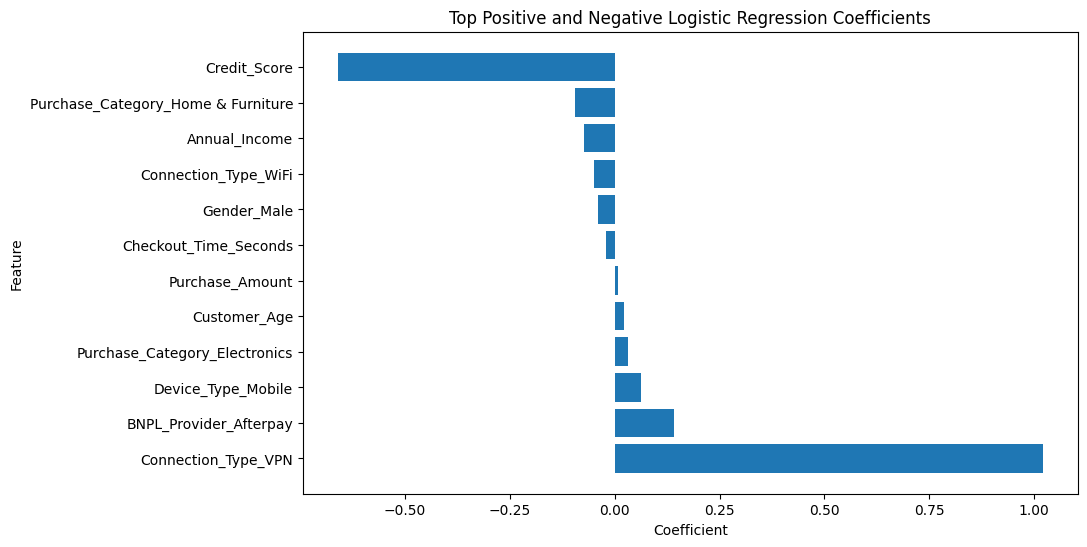

In [ ]:
# Plot top coefficients

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)
plot_df = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Feature"], plot_df["Coefficient"])
plt.title("Top Positive and Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()